Review Sentiment Analysis Worfkflow:

<pre>
               Input (Review)
                         |
      Calculate Sentiment (Positive/Negative)
                         |
                    Sentiment Checker
                         |
    +--------------------+---------------------+
    |                                          |
  Positive                                  Negative 
    |                                          |
Return a Positive                          Run diagnosis (return JSON for Issue Type,
  Response                                   User Tone, Urgency)
   |                                           |
   |                                       Return a framed negative Response
   +---------------------+---------------------+
                         |
                       Output
</pre>


In [238]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
load_dotenv()

True

In [239]:
# model = ChatGoogleGenerativeAI(model="gemini-2.5-pro")
model = ChatOpenAI(model="gpt-4.1")

In [240]:
class SentimentAnalysis(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description="Sentiment of the Review")
    

In [241]:
class diagnosisAnalysis(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [242]:
structured_model = model.with_structured_output(SentimentAnalysis)
structured_model1= model.with_structured_output(diagnosisAnalysis)

In [243]:
structured_model.invoke("The phone quality is nice").sentiment
structured_model1.invoke("The phone quality is very bad")

diagnosisAnalysis(issue_type='Performance', tone='disappointed', urgency='medium')

In [244]:
class Review_sentiment(TypedDict):
    review: str
    sentiment : Literal["positive","negative"]
    diagnosis: dict
    message:str

In [245]:
graph = StateGraph(Review_sentiment)

In [246]:
def find_sentiment(state:Review_sentiment):

    prompt= f"Find the sentiment of the review : {state['review']}"

    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment':sentiment}

In [247]:
def sentiment_check(state:Review_sentiment) -> Literal["positive_sentiment","run_diagnosis"]:

    if state['sentiment'] == "positive":
        return "positive_sentiment"
    else:
        return "run_diagnosis"

In [248]:
def positive_sentiment(state:Review_sentiment):

    prompt = f"Frame a nice positive greeting message for the custormer based on the review : {state['review']}"

    message = model.invoke(prompt).content

    return {'message':message}

In [249]:
def run_diagnosis(state:Review_sentiment):

    prompt = f"Diagnosis the negative review : {state['review']} \n\n and return the issue_type, tone and urgency"

    diagnosis = structured_model1.invoke(prompt)

    dict1 = {'issue_type':diagnosis.issue_type,'tone':diagnosis.tone,'urgency':diagnosis.urgency}

    return {'diagnosis':dict1}



In [250]:
def negative_sentiment(state:Review_sentiment):

    prompt = f"Frame a negative message for the custormer based on the review : {state['review']} and diagnosis parameters : {state['diagnosis']}"

    message = model.invoke(prompt).content

    return {'message':message}


In [251]:
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_sentiment",positive_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_sentiment",negative_sentiment)

In [252]:
graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges("find_sentiment",sentiment_check)
graph.add_edge("positive_sentiment",END)
graph.add_edge("run_diagnosis","negative_sentiment")
graph.add_edge("negative_sentiment",END)
graph.add_edge('find_sentiment',END)

In [253]:
workflow =graph.compile()

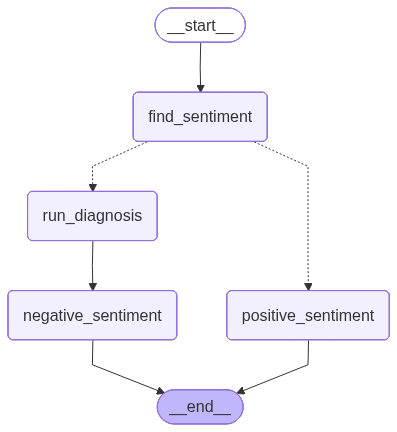

In [254]:
workflow

In [255]:
input1 = {'review':"The phone quality is very worst and even did not like the functionality for the phone behaves very bad"}


In [256]:
workflow.invoke(input1)

{'review': 'The phone quality is very worst and even did not like the functionality for the phone behaves very bad',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'UX', 'tone': 'frustrated', 'urgency': 'high'},
 'message': "Certainly! Here's a negative response message to the customer that acknowledges their feedback, matches their frustration, and uses an empathetic yet straightforward tone, considering their urgency and the 'UX' issue type:\n\n---\n\nDear Customer,\n\nWe are truly sorry to hear about your experience with our phone. We understand your frustration regarding both the quality and the functionality, and we acknowledge that the device has not met your expectations, especially in terms of user experience. \n\nYour feedback about the phone behaving poorly and the overall dissatisfaction is very concerning to us. We take issues like these seriously and regret any inconvenience caused. Please rest assured that we are prioritizing this matter, and we would like to assi

In [257]:
input2 = {'review':"The phone quality is very good and even I liked the colou of phone its look wonderful Nice Product"}


In [258]:
workflow.invoke(input2)

{'review': 'The phone quality is very good and even I liked the colou of phone its look wonderful Nice Product',
 'sentiment': 'positive',
 'message': 'Certainly! Here’s a positive greeting message based on the review:\n\n---\n\nThank you so much for your wonderful feedback! We’re thrilled to hear that you’re enjoying the quality and color of your new phone. It’s always our goal to provide products that delight our customers, and your kind words truly motivate us. Enjoy your new phone, and thank you for choosing us!\n\n---'}